# Exploratory Data Analysis: `schools_data.csv`

This notebook performs EDA on Singapore primary school features, validates data quality, and uses plots to support key findings.

Key questions:
- What is the structure and quality of the dataset?
- Which variables have the strongest relationship with `top_psle_score`?
- Which schools have the highest admission demand pressure?


In [1]:
# Install dependencies if needed (safe to re-run).
# Important: this keeps the notebook self-contained on fresh environments.
%pip install -q pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [3]:
# Resolve dataset path robustly so the notebook works from either project root
# or the school_scoring folder.
candidate_paths = [
    Path('schools_data.csv'),
    Path('school_scoring/schools_data.csv'),
]

for p in candidate_paths:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError('Could not find schools_data.csv in expected locations.')

df = pd.read_csv(data_path)
df.head()

,school_name,address,postal_code,nature_code,sap_ind,autonomous_ind,gifted_ind,P1_demand,P2A_demand,P2B_demand,P2C_demand,P2CS_demand,subject_count,distprog_count,cca_clubs,cca_others,cca_sports,cca_uniformed,cca_arts,affiliation_count,top_psle_score
0,ADMIRALTY PRIMARY SCHOOL,11 WOODLANDS CIRCLE,738907,CO-ED SCHOOL,0,0,0,0.590,0.590,1.220,1.840,0.000,24,2,5,0,5,2,6,0,0
1,AHMAD IBRAHIM PRIMARY SCHOOL,10 YISHUN STREET 11,768643,CO-ED SCHOOL,0,0,0,0.300,0.060,0.000,0.180,0.170,21,2,3,1,4,1,4,0,0
2,AI TONG SCHOOL,100 Bright Hill Drive,579646,CO-ED SCHOOL,1,0,0,0.530,1.190,2.670,1.980,0.000,14,2,4,0,6,2,5,0,1
3,ALEXANDRA PRIMARY SCHOOL,2A Prince Charles Crescent,159016,CO-ED SCHOOL,0,0,0,0.480,0.530,0.130,1.210,0.000,22,2,6,0,7,1,5,0,0
4,ANCHOR GREEN PRIMARY SCHOOL,31 Anchorvale Drive,544969,CO-ED SCHOOL,0,0,0,0.390,0.290,0.000,0.200,0.670,30,2,4,0,4,1,5,0,0


In [4]:
# Basic structure checks
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nColumns:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Shape: 182 rows x 21 columns

Columns:
['school_name', 'address', 'postal_code', 'nature_code', 'sap_ind', 'autonomous_ind', 'gifted_ind', 'P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand', 'subject_count', 'distprog_count', 'cca_clubs', 'cca_others', 'cca_sports', 'cca_uniformed', 'cca_arts', 'affiliation_count', 'top_psle_score']

Data types:


,dtype
school_name,object
address,object
postal_code,int64
nature_code,object
sap_ind,int64
autonomous_ind,int64
gifted_ind,int64
P1_demand,float64
P2A_demand,float64
P2B_demand,float64


In [5]:
# Data quality checks
missing = df.isna().sum().sort_values(ascending=False)
duplicate_school_names = df['school_name'].duplicated().sum()

print('Missing values per column:')
display(missing.to_frame('missing_count'))
print(f'Duplicate school_name rows: {duplicate_school_names}')

Missing values per column:


,missing_count
school_name,0
address,0
postal_code,0
nature_code,0
sap_ind,0
autonomous_ind,0
gifted_ind,0
P1_demand,0
P2A_demand,0
P2B_demand,0


Duplicate school_name rows: 0


In [6]:
# Important: postal_code is numeric-looking but should be treated as an identifier.
id_like_columns = ['postal_code']

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in id_like_columns]
categorical_cols = [c for c in df.columns if c not in numeric_cols and c not in id_like_columns]

print('Numeric columns for analysis:')
print(numeric_cols)
print('\nCategorical columns:')
print(categorical_cols)

Numeric columns for analysis:
['sap_ind', 'autonomous_ind', 'gifted_ind', 'P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand', 'subject_count', 'distprog_count', 'cca_clubs', 'cca_others', 'cca_sports', 'cca_uniformed', 'cca_arts', 'affiliation_count', 'top_psle_score']

Categorical columns:
['school_name', 'address', 'nature_code']


In [7]:
# Numeric summary statistics
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
sap_ind,182.000,0.082,0.276,0.000,0.000,0.000,0.000,1.000
autonomous_ind,182.000,0.016,0.128,0.000,0.000,0.000,0.000,1.000
gifted_ind,182.000,0.049,0.217,0.000,0.000,0.000,0.000,1.000
P1_demand,182.000,0.465,0.125,0.000,0.372,0.495,0.560,0.730
P2A_demand,182.000,0.539,0.465,0.040,0.173,0.330,0.818,2.650
P2B_demand,182.000,0.463,0.674,0.000,0.010,0.060,0.725,2.700
P2C_demand,182.000,1.053,0.858,0.080,0.380,0.890,1.488,5.750
P2CS_demand,182.000,0.416,0.595,0.000,0.000,0.215,0.670,5.290
subject_count,182.000,26.791,5.481,12.000,24.000,29.000,29.000,52.000
distprog_count,182.000,2.033,0.492,0.000,2.000,2.000,2.000,6.000


,count
nature_code,
CO-ED SCHOOL,158
GIRLS' SCHOOL,15
BOYS' SCHOOL,9


/var/folders/2s/sj7n8qbs5838w7lml1xsqlv40000gn/T/ipykernel_19628/4137341779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='nature_code', order=nature_counts.index, palette='Set2')


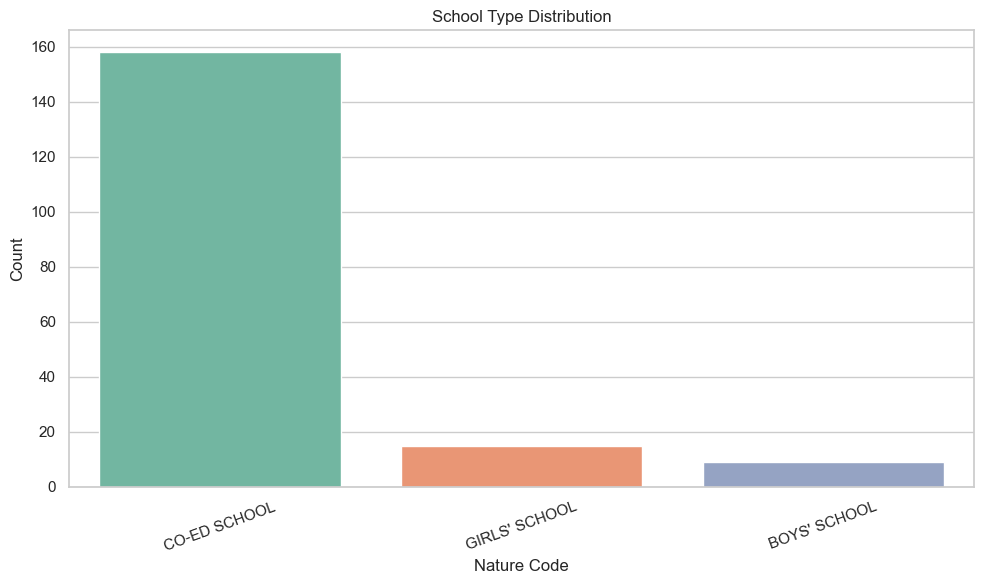

In [8]:
# Distribution of school types
nature_counts = df['nature_code'].value_counts()
display(nature_counts.to_frame('count'))

ax = sns.countplot(data=df, x='nature_code', order=nature_counts.index, palette='Set2')
ax.set_title('School Type Distribution')
ax.set_xlabel('Nature Code')
ax.set_ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,percentage
sap_ind,8.240
top_psle_score,5.490
gifted_ind,4.950
autonomous_ind,1.650


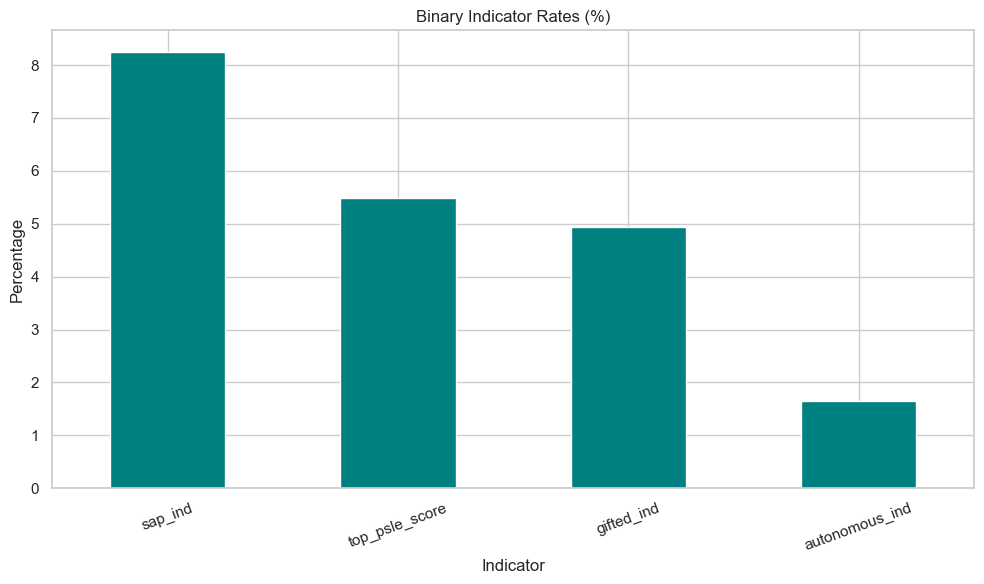

In [9]:
# Binary indicator prevalence
binary_cols = ['sap_ind', 'autonomous_ind', 'gifted_ind', 'top_psle_score']
indicator_rates = df[binary_cols].mean().sort_values(ascending=False)
display((indicator_rates * 100).round(2).to_frame('percentage'))

ax = indicator_rates.mul(100).plot(kind='bar', color='teal')
ax.set_title('Binary Indicator Rates (%)')
ax.set_xlabel('Indicator')
ax.set_ylabel('Percentage')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,school_name,total_demand
0,PRINCESS ELIZABETH PRIMARY SCHOOL,9.520
1,NAN HUA PRIMARY SCHOOL,8.370
2,DAZHONG PRIMARY SCHOOL,7.680
3,SOUTH VIEW PRIMARY SCHOOL,7.120
4,ST. HILDA'S PRIMARY SCHOOL,6.830
5,GONGSHANG PRIMARY SCHOOL,6.590
6,HOLY INNOCENTS' PRIMARY SCHOOL,6.590
7,ROSYTH SCHOOL,6.590
8,NAN CHIAU PRIMARY SCHOOL,6.410
9,AI TONG SCHOOL,6.370


/var/folders/2s/sj7n8qbs5838w7lml1xsqlv40000gn/T/ipykernel_19628/1013411121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_demand, y='school_name', x='total_demand', palette='viridis')


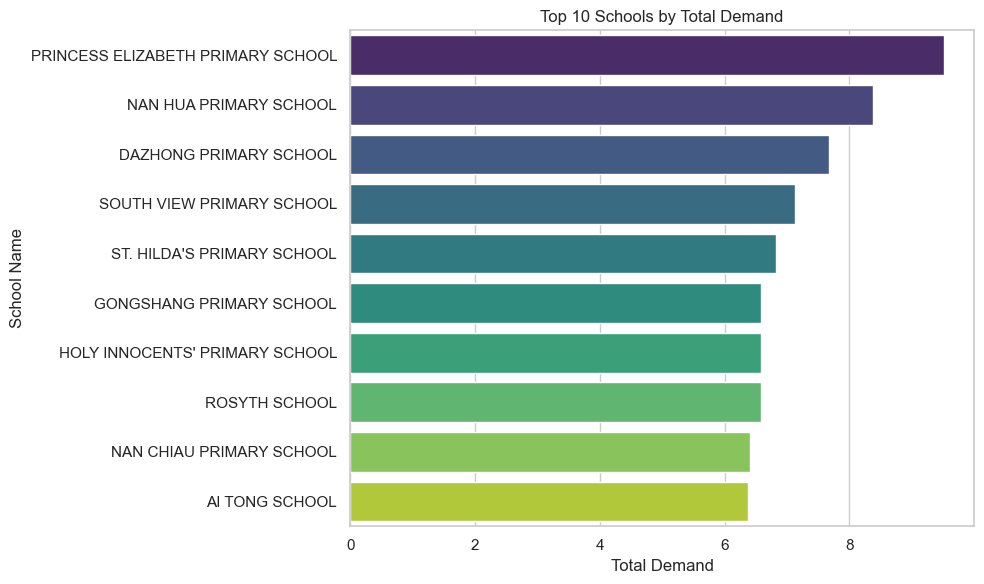

In [10]:
# Engineer total demand feature used in findings.
demand_cols = ['P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand']
df['total_demand'] = df[demand_cols].sum(axis=1)

top10_demand = df.nlargest(10, 'total_demand')[['school_name', 'total_demand']].reset_index(drop=True)
display(top10_demand)

ax = sns.barplot(data=top10_demand, y='school_name', x='total_demand', palette='viridis')
ax.set_title('Top 10 Schools by Total Demand')
ax.set_xlabel('Total Demand')
ax.set_ylabel('School Name')
plt.tight_layout()
plt.show()

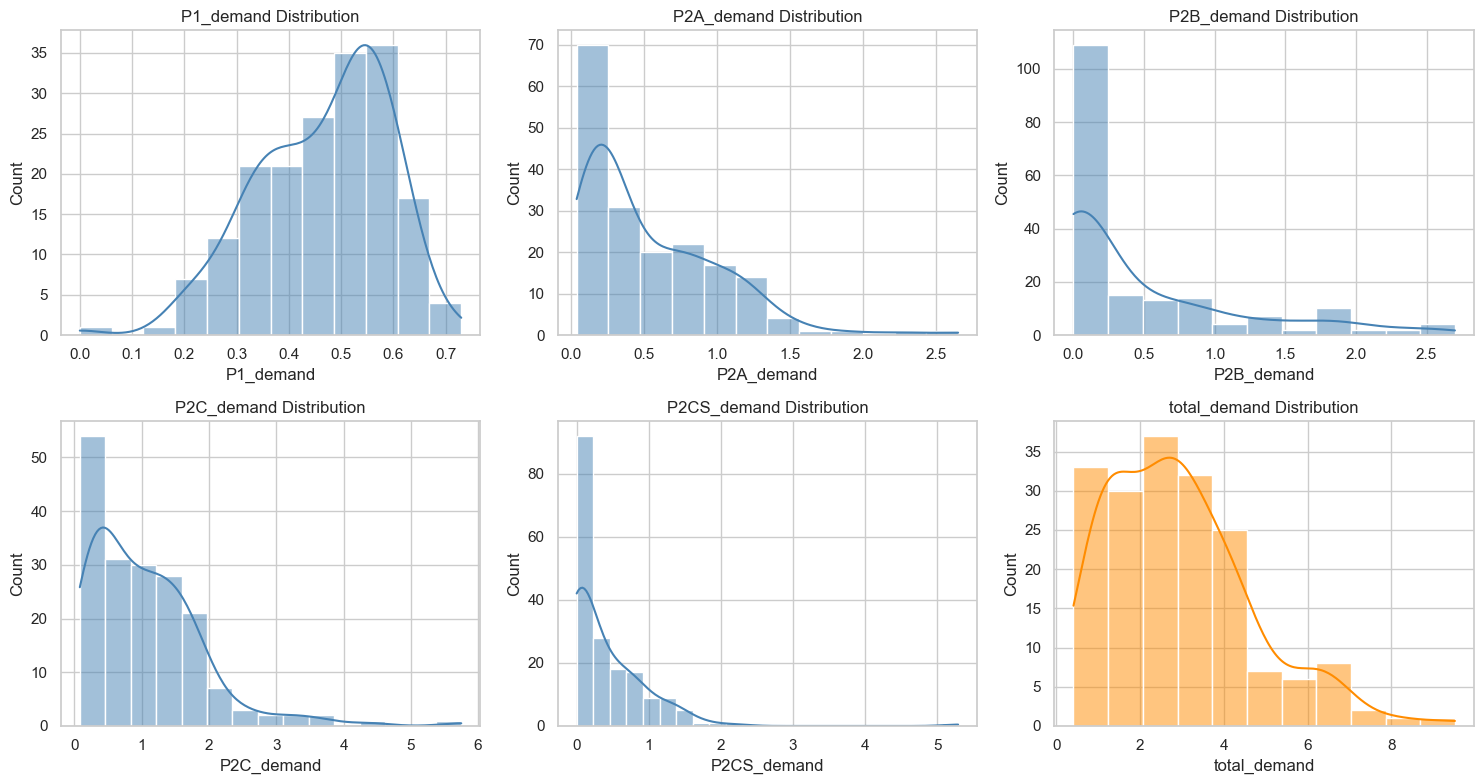

In [11]:
# Demand distributions by phase
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(demand_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')

# Last panel for total_demand
sns.histplot(df['total_demand'], kde=True, ax=axes[-1], color='darkorange')
axes[-1].set_title('total_demand Distribution')

plt.tight_layout()
plt.show()

,count
top_psle_score,
0,172
1,10


/var/folders/2s/sj7n8qbs5838w7lml1xsqlv40000gn/T/ipykernel_19628/500750766.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='top_psle_score', y='total_demand', palette='Set3')


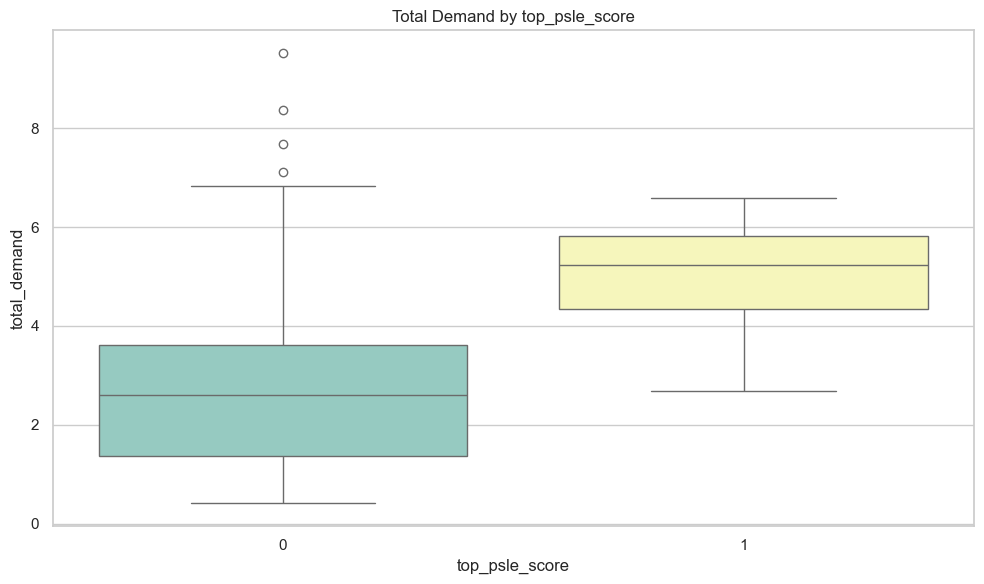

In [12]:
# Compare demand by top_psle_score class.
# Important: class is imbalanced, so always check group sizes before interpreting.
group_sizes = df['top_psle_score'].value_counts().sort_index()
display(group_sizes.to_frame('count'))

ax = sns.boxplot(data=df, x='top_psle_score', y='total_demand', palette='Set3')
ax.set_title('Total Demand by top_psle_score')
ax.set_xlabel('top_psle_score')
ax.set_ylabel('total_demand')
plt.tight_layout()
plt.show()

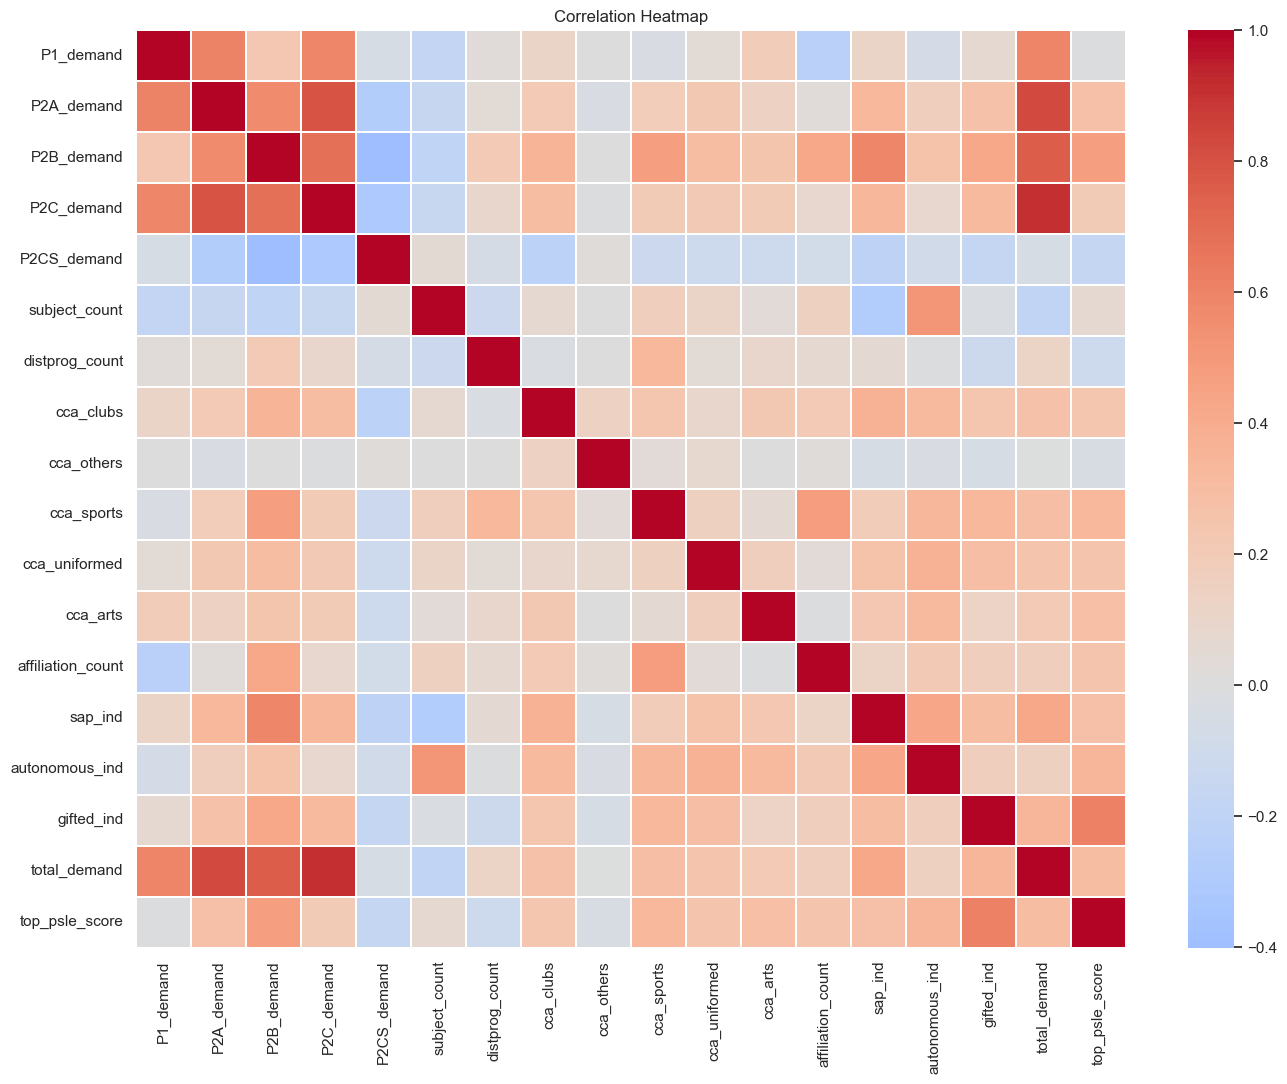

,corr_with_top_psle_score
gifted_ind,0.612
P2B_demand,0.474
autonomous_ind,0.348
cca_sports,0.333
total_demand,0.297
cca_arts,0.288
sap_ind,0.278
P2A_demand,0.274
cca_uniformed,0.255
affiliation_count,0.251


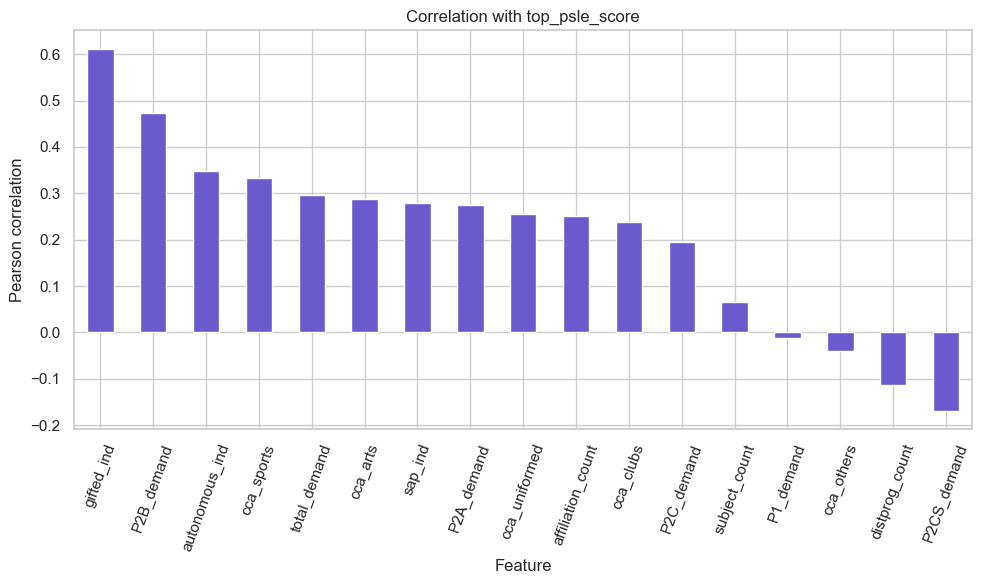

In [13]:
# Correlation matrix for core numeric variables
corr_cols = [
    'P1_demand', 'P2A_demand', 'P2B_demand', 'P2C_demand', 'P2CS_demand',
    'subject_count', 'distprog_count', 'cca_clubs', 'cca_others', 'cca_sports',
    'cca_uniformed', 'cca_arts', 'affiliation_count', 'sap_ind', 'autonomous_ind',
    'gifted_ind', 'total_demand', 'top_psle_score'
]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr_with_target = corr['top_psle_score'].drop('top_psle_score').sort_values(ascending=False)
display(corr_with_target.to_frame('corr_with_top_psle_score'))

ax = corr_with_target.plot(kind='bar', color='slateblue')
ax.set_title('Correlation with top_psle_score')
ax.set_xlabel('Feature')
ax.set_ylabel('Pearson correlation')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

top_psle_score,0,1
nature_code,,
BOYS' SCHOOL,77.780,22.220
CO-ED SCHOOL,97.470,2.530
GIRLS' SCHOOL,73.330,26.670


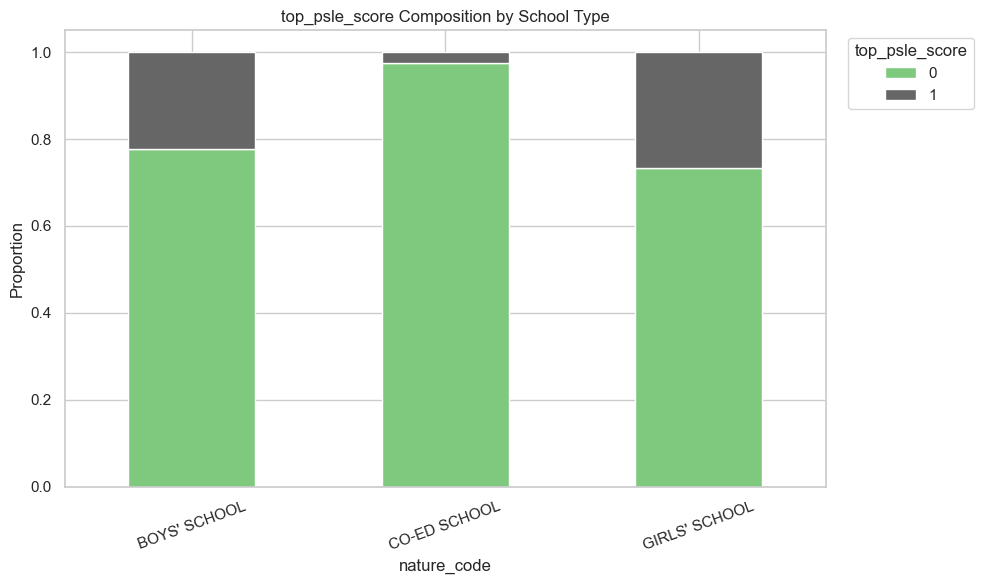

In [14]:
# top_psle_score rate by school type
nature_psle = pd.crosstab(df['nature_code'], df['top_psle_score'], normalize='index')
display((nature_psle * 100).round(2))

ax = nature_psle.plot(kind='bar', stacked=True, colormap='Accent')
ax.set_title('top_psle_score Composition by School Type')
ax.set_xlabel('nature_code')
ax.set_ylabel('Proportion')
plt.xticks(rotation=20)
plt.legend(title='top_psle_score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Interpretation notes
- `gifted_ind`, `P2B_demand`, `total_demand`, and selected CCA features show stronger positive associations with `top_psle_score`.
- `top_psle_score` is rare, so treat correlations as directional evidence, not causal proof.
- Use this EDA as a basis for feature engineering and class-imbalance-aware modeling next.
